# Capstone Assignment 20.1: Initial Report and Exploratory Data Analysis

**Overview**: This notebook provides exploratory data analysis and a baseline model on the [Real / Fake Job Posting Prediction Dataset](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction), making use of the article accompanying the dataset [here](https://www.icsd.aegean.gr/publication_files/290421648.pdf)



### Section 1: Understanding the Data

Before modeling, we confirm:
- the prediction target (binary classification),
- feature types (numeric vs categorical),
- missing values
- class imbalance 

### Section 2: Reading the Data

Use pandas to read in the dataset `fake_job_postings.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

import re
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MaxAbsScaler
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB 
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from wordcloud import WordCloud


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay,
)

import importlib
import helpers.salary_features as sf
importlib.reload(sf)

from helpers.salary_features import parse_salary_range
RANDOM_STATE=42

#### Helper Functions

In [2]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'na_count': df.isna().sum(),
    'na_percentage': (df.isna().sum() / len(df)) * 100,
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.dropna().sample().iloc[0]
  })

In [3]:
def extract_country_from_location(location):
    """Extract country from location string"""
    if pd.isna(location):
        return 'Unknown'
    
    # Common patterns
    location = str(location).strip()
    
    # Check for country codes or full country names at the end
    parts = location.split(',')
    if len(parts) > 0:
        last_part = parts[-1].strip()
        
        # Map common country indicators
        country_map = {
            'US': 'USD', 'USA': 'USD', 'United States': 'USD',
            'UK': 'GBP', 'GB': 'GBP', 'United Kingdom': 'GBP',
            'CA': 'CAD', 'Canada': 'CAD',
            'AU': 'AUD', 'Australia': 'AUD',
            'IN': 'INR', 'India': 'INR',
            'DE': 'EUR', 'Germany': 'EUR',
            'FR': 'EUR', 'France': 'EUR',
            # Add more mappings as needed
        }
        
        return country_map.get(last_part, 'Unknown')
    
    return 'Unknown'

In [4]:
def detect_salary_outliers(df):
    """Detect salary outliers using IQR method"""
    Q1 = df['salary_mid_usd'].quantile(0.25)
    Q3 = df['salary_mid_usd'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[
        (df['salary_mid_usd'] < lower_bound) | 
        (df['salary_mid_usd'] > upper_bound)
    ]

In [5]:
job_postings_df = pd.read_csv('data/fake_job_postings.csv')
print("Shape:", job_postings_df.shape)

Shape: (17880, 18)


In [6]:
job_postings_df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [7]:
job_postings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Observations

Given the column info and head samples, we can deduce the following:
- job_id is a unique ID which likely has little correlation to fraudulence
- salary range likely correlates to region/country. An unrealistic range -- too wide, or atypical to the job title - could correlate to fraudulency

### Section 3: Understanding the Features

Here, we examine the data, evaluating missingness, categorical vs text features.

In [8]:
job_postings_df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
data_quality_report(job_postings_df)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
job_id,int64,17880,0,0,0.000000,0.000000,17880,6519
title,object,17880,0,0,0.000000,0.000000,11231,WAREHOUSE ASSOCIATE
location,object,17534,346,346,1.935123,1.935123,3105,"US, TX, Austin"
department,object,6333,11547,11547,64.580537,64.580537,1337,WWAREHOUSE ASSOCIATE
salary_range,object,2868,15012,15012,83.959732,83.959732,874,23000-26000
company_profile,object,14572,3308,3308,18.501119,18.501119,1709,The Accion story began more than 100 years ag...
description,object,17879,1,1,0.005593,0.005593,14801,Shipping ResponsibilitiesThe shipping function...
requirements,object,15184,2696,2696,15.078300,15.078300,11967,"MUST BE ABLE TO PASS A BACKGROUND CHECK , DRUG..."
benefits,object,10668,7212,7212,40.335570,40.335570,6204,ALL FULL- TIME BENEFITS
telecommuting,int64,17880,0,0,0.000000,0.000000,2,0


In [10]:
print(f"Total duplicated rows is {job_postings_df.duplicated().sum()}")

Total duplicated rows is 0


### Section 4: Most Missing Columns

Fraudulent postings often have more missing fields, e.g. no company logo, salary range, company profile.

fraudulent                  0         1
salary_range         0.844540  0.742494
company_profile      0.159927  0.677829
department           0.647467  0.613164
required_education   0.449865  0.520785
required_experience  0.388797  0.502309
benefits             0.402492  0.420323
function             0.359586  0.389145
industry             0.272011  0.317552
employment_type      0.189844  0.278291
requirements         0.149406  0.177829
location             0.019219  0.021940
description          0.000000  0.001155
job_id               0.000000  0.000000
telecommuting        0.000000  0.000000
has_questions        0.000000  0.000000
has_company_logo     0.000000  0.000000
title                0.000000  0.000000
fraudulent           0.000000  0.000000


/var/folders/zq/7j33ffkd46vd0yzyrk5qyj140000gn/T/ipykernel_4091/4154569629.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_class = job_postings_df.groupby('fraudulent').apply(


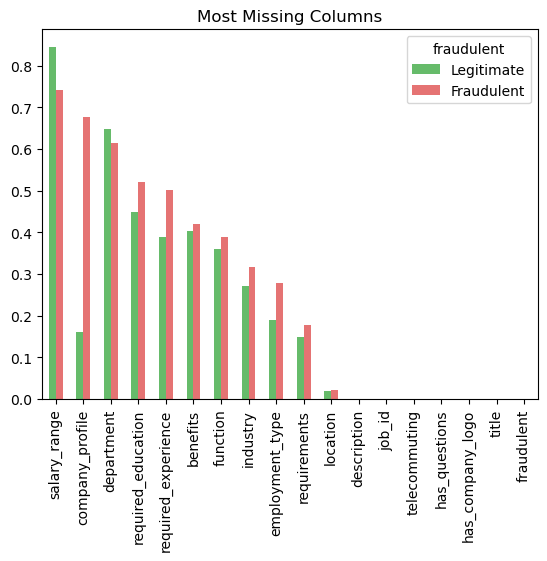

In [11]:
missing_by_class = job_postings_df.groupby('fraudulent').apply(
    lambda x: x.isnull().mean()
).T.sort_values(by=1, ascending=False)
print(missing_by_class)

##     ct.plot(kind='bar', color=['#E57373', '#66BB6A'], width=0.8, ax=axes[idx])
missing_plot = missing_by_class.plot(kind='bar', color=['#66BB6A', '#E57373'], legend=['Legitimate', 'Fraudulent'], title="Most Missing Columns")
legend = missing_plot.get_legend()

for text, label in zip(legend.get_texts(), ['Legitimate', 'Fraudulent']):
    text.set_text(label)

In [12]:
job_postings_df['has_salary_range'] = job_postings_df['salary_range'].notna().astype(int)
job_postings_df['has_company_profile'] = job_postings_df['company_profile'].notna().astype(int)
job_postings_df['missing_count'] = job_postings_df.isnull().sum(axis=1)

## Observations

Here, we can see that salary range has the most missing data, with company_profile, department, required_education closely trailing behind.

Here,  lack of a company profile could be a strong indicator of fraudulency.

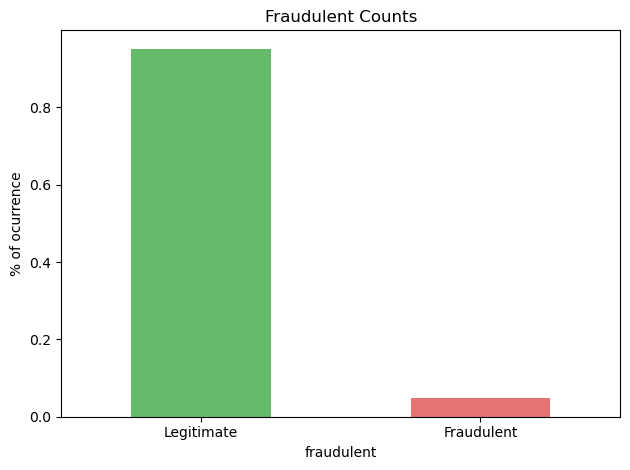

In [13]:
fraudulent_counts = job_postings_df['fraudulent'].value_counts(normalize=True)

fraudulent_counts.plot(title="Fraudulent Counts", kind="bar", color=['#66BB6A', '#E57373'])
plt.ylabel("% of ocurrence")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])
plt.tick_params(axis='x', rotation=0)
plt.savefig('images/fraudulent_counts.png')
plt.tight_layout()

### Section 5: Understanding the Task

**Business objective:** predict which job postings are fraudulent vs legitimate, so applicants can avoid providing PPI to scammers.

**ML objective:** learn a mapping from job application features to a binary response label and evaluate competing classifiers using cross-valdiation and a held-out test set.

### Section 6: Understanding and Visualizing Features

The following columns:
- description
- company_profile
- requirements
- benefits

are text columns suited for NLP feature engineering.

In [14]:
text_columns = ['description', 'company_profile', 'requirements', 'benefits'] 

In [15]:
num_cols = [col for col in job_postings_df.select_dtypes(include=[np.number]).columns.tolist() if col != "job_id"]
cat_cols = [col for col in job_postings_df.select_dtypes(include='object').columns.tolist() if col not in text_columns]

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent', 'has_salary_range', 'has_company_profile', 'missing_count']
Categorical features: ['title', 'location', 'department', 'salary_range', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']


In [16]:
for col in cat_cols + text_columns:
    job_postings_df[col] = job_postings_df[col].fillna(f"unknown {col} value")

data_quality_report(job_postings_df)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
job_id,int64,17880,0,0,0.0,0.0,17880,13078
title,object,17880,0,0,0.0,0.0,11231,Senior Backend API/ Web Services Engineer
location,object,17880,0,0,0.0,0.0,3106,"US, CA, San Francisco"
department,object,17880,0,0,0.0,0.0,1338,Engineering
salary_range,object,17880,0,0,0.0,0.0,875,unknown salary_range value
company_profile,object,17880,0,0,0.0,0.0,1710,unknown company_profile value
description,object,17880,0,0,0.0,0.0,14802,At Shyp we're using technology to change the w...
requirements,object,17880,0,0,0.0,0.0,11968,5+ years of experience working large scale app...
benefits,object,17880,0,0,0.0,0.0,6205,Whichever computer setup you want – macbook ai...
telecommuting,int64,17880,0,0,0.0,0.0,2,0


### Understanding Numerical Correlations

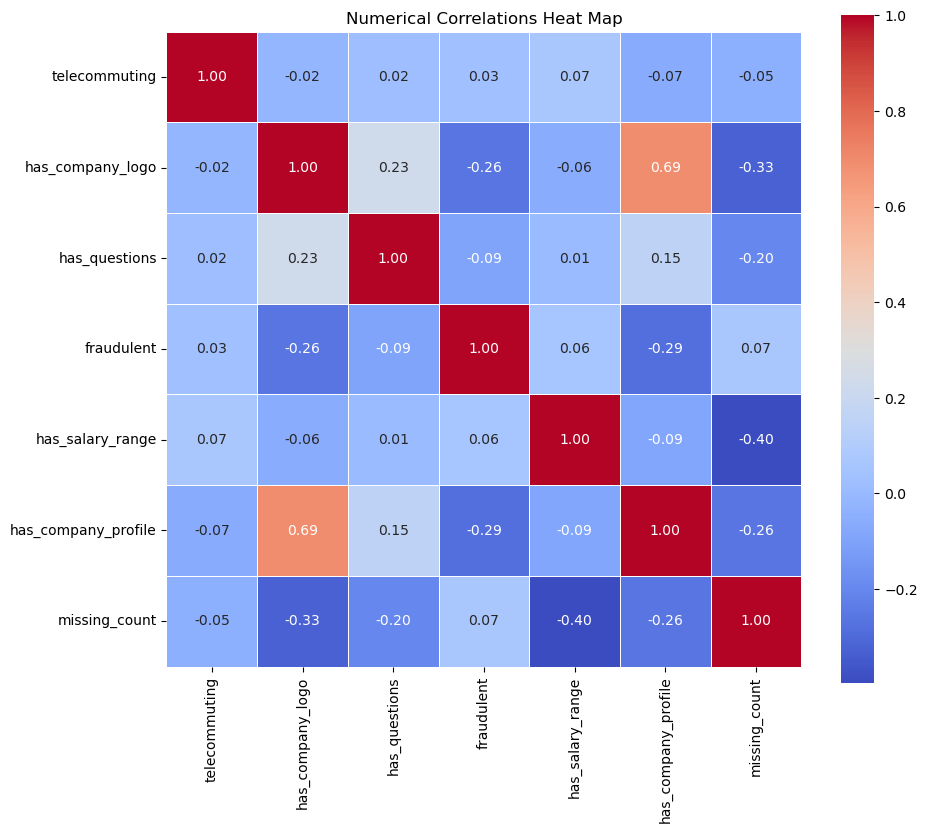

In [17]:
corr_matrix = job_postings_df[num_cols].corr()
n = len(corr_matrix.columns)

fig, ax = plt.subplots(figsize=(n * 1.4, n * 1.2))

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidth=0.4, linecolor='white', square=True)
plt.savefig('images/numerical_correlations_heatmap.png')
plt.title("Numerical Correlations Heat Map")
plt.tight_layout()

#### Observations

Of the four numerical columns, `has_questions` and `has_company_logo` skew a job posting towards legitimate. Only `telecommuting` displays a positive correlation to fraudulency at `0.02`.

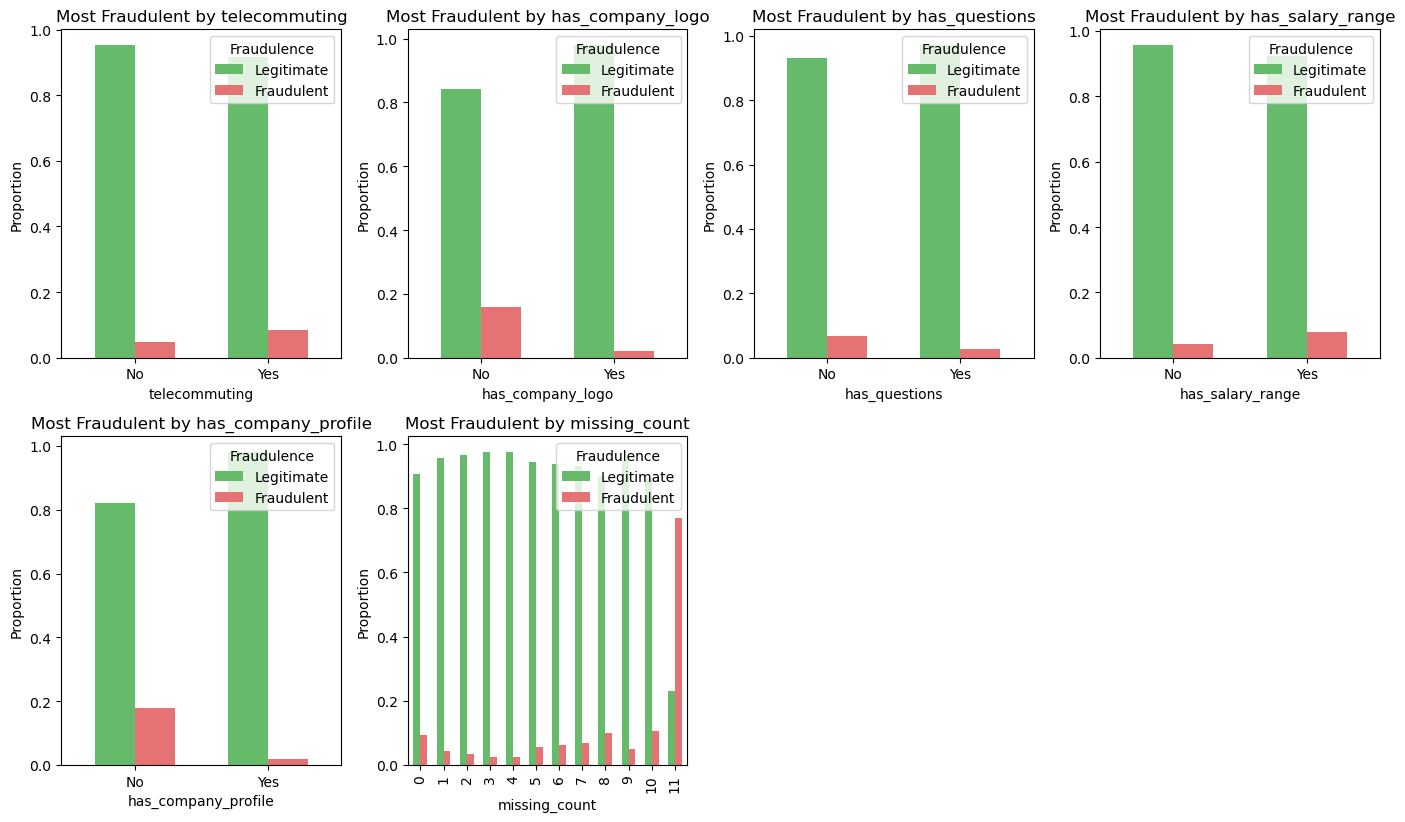

In [18]:
num_to_plot = [c for c in num_cols if c not in ['job_id', 'fraudulent'] and not bool(re.search(r'_len', col))]

# Calculate rows and columns for better layout
n_plots = len(num_to_plot)
n_cols = 4  # or however many columns you want
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

# This safely handles 1x1, 1D, and 2D arrays identically
axes = np.array(axes).flatten()

# Plot each distribution
for idx, col in enumerate(num_to_plot):
   
    ct = pd.crosstab(job_postings_df[col], job_postings_df['fraudulent'], normalize='index')
    
    # Stacked bar chart
    ct.plot(kind='bar', 
            ax=axes[idx], 
            color=['#66BB6A', '#E57373'],
            width=0.6)
    
    axes[idx].set_title(f"Most Fraudulent by {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Proportion")
    
    if job_postings_df[col].nunique() == 2:
        axes[idx].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[idx].legend(['Legitimate', 'Fraudulent'], title='Fraudulence')

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('images/numerical_bar_plots.png')
plt.show()

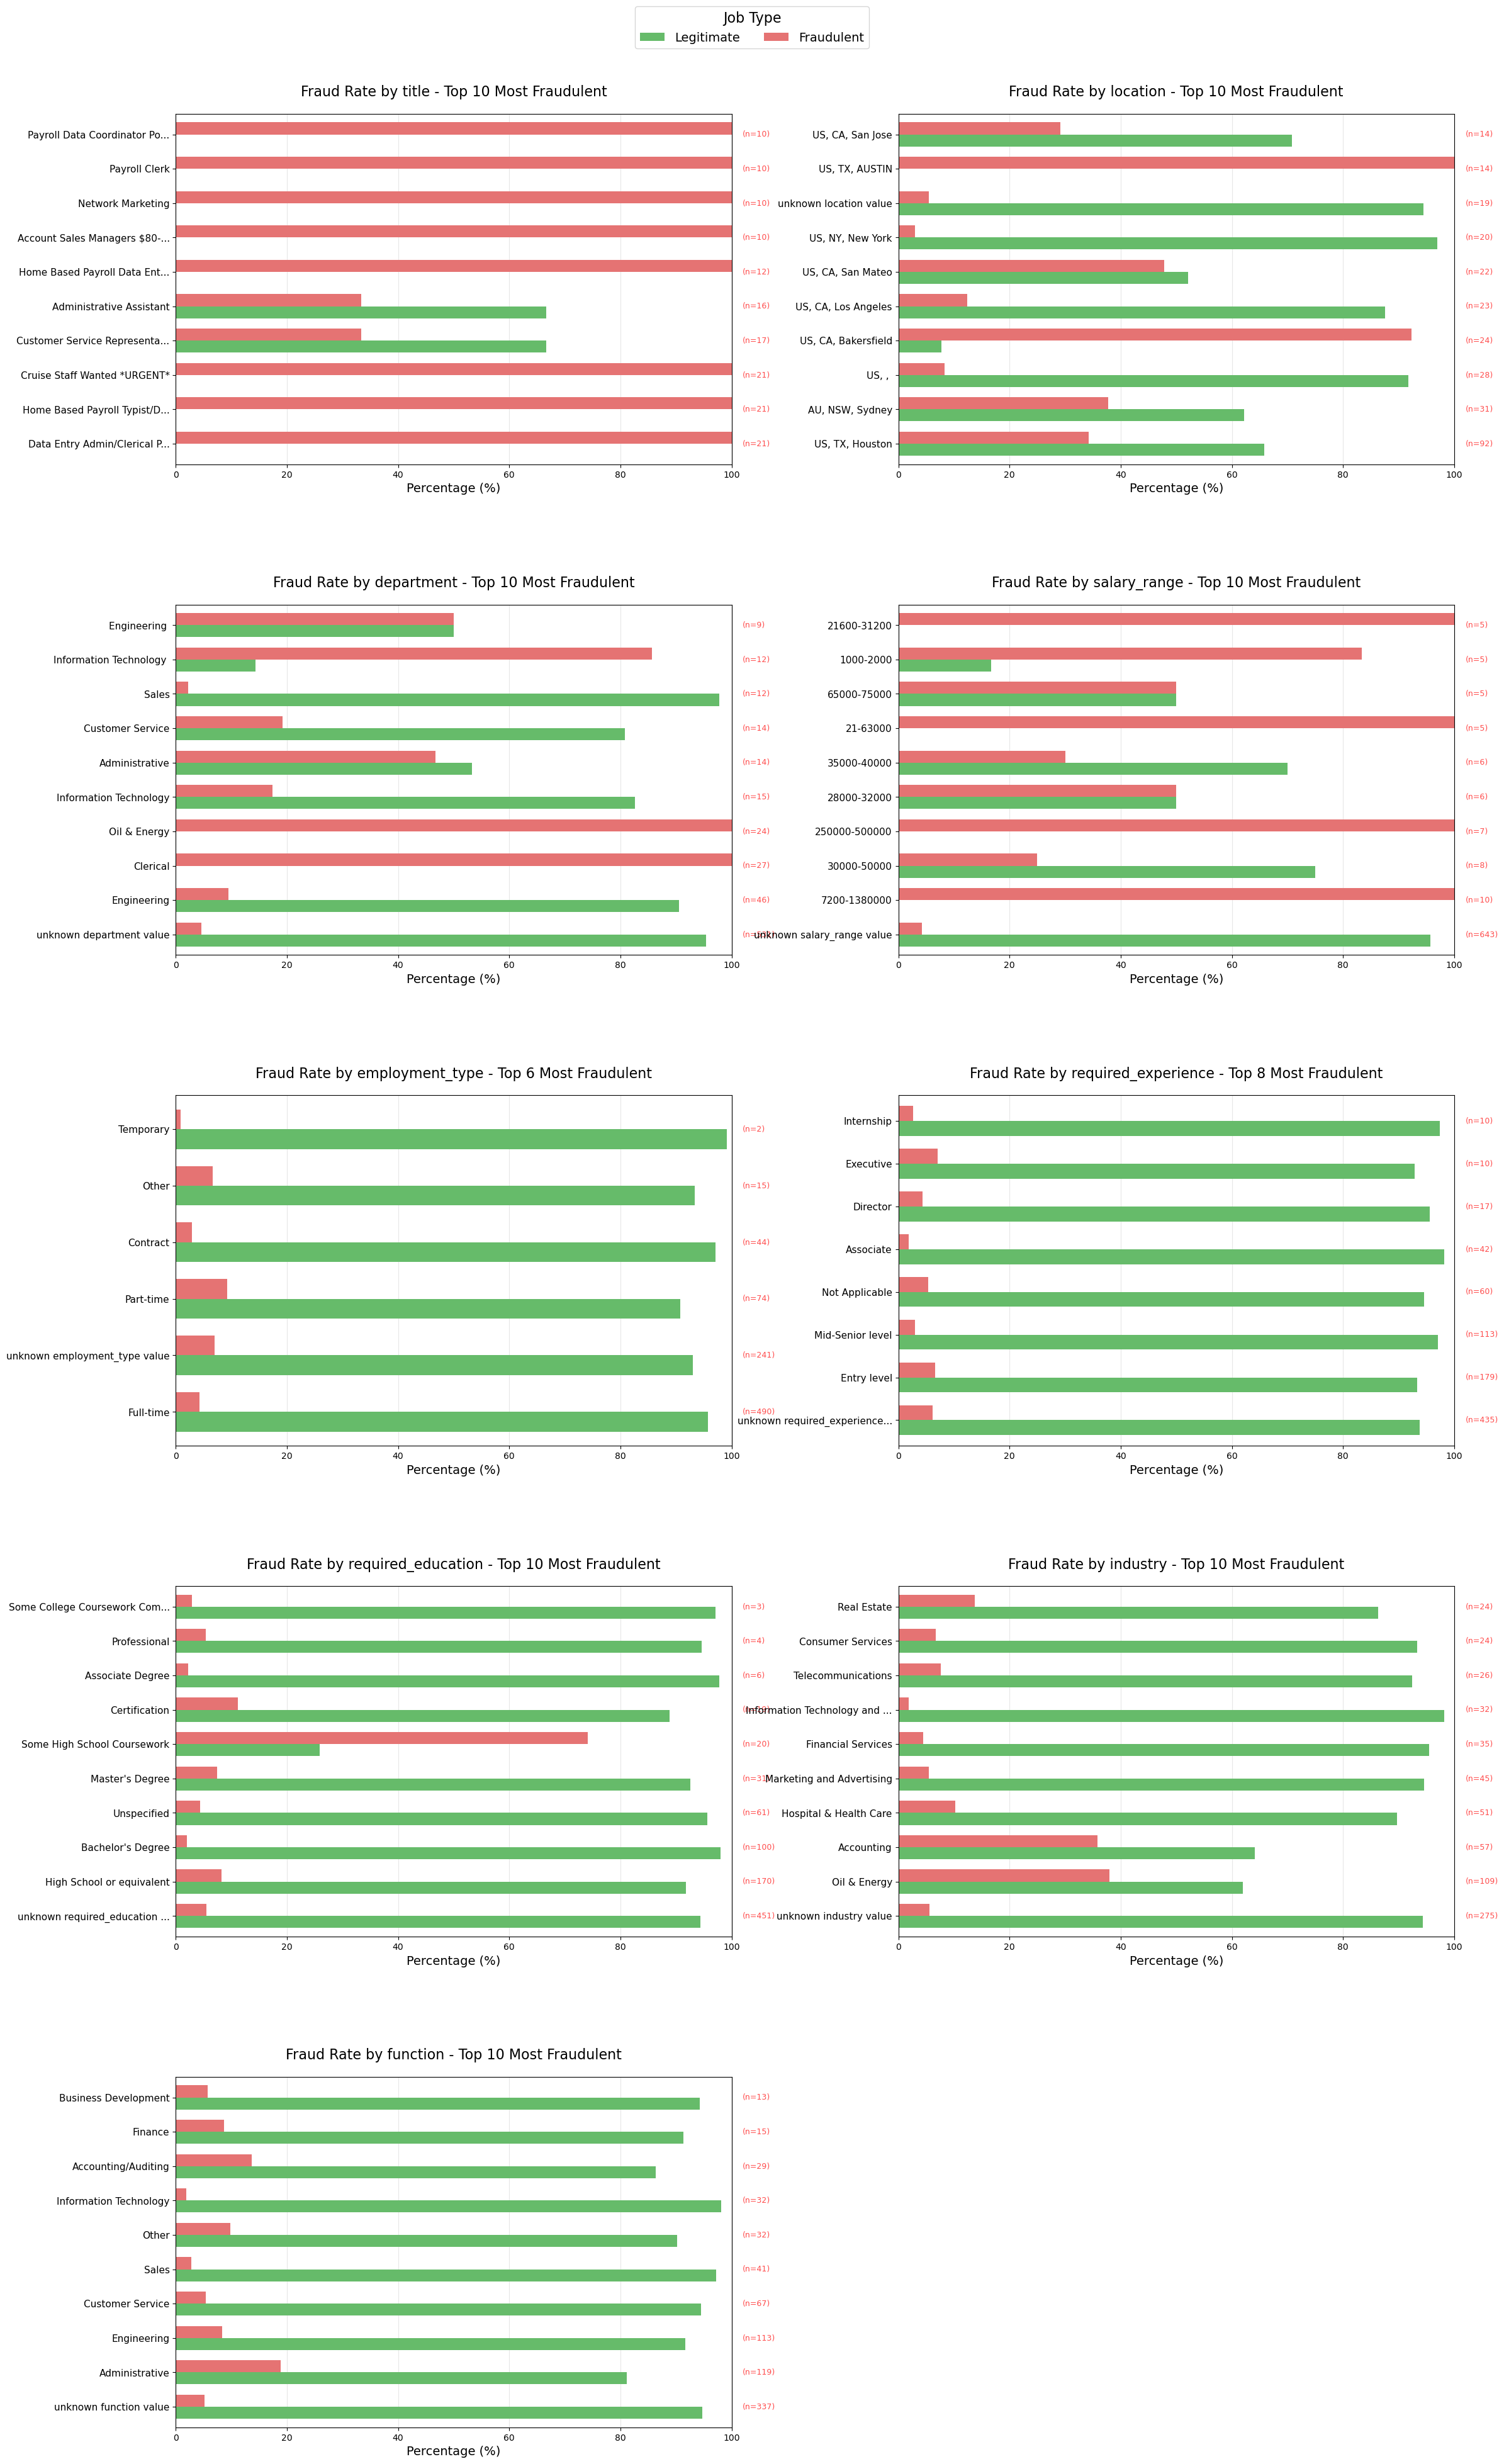

In [19]:
cat_to_plot = [c for c in cat_cols if c not in ['fraudulent'] + text_columns]

# Calculate rows and columns for better layout
n_plots = len(cat_to_plot)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure with even larger size for horizontal bars
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each categorical variable
for idx, col in enumerate(cat_to_plot):
    # Get categories with highest fraud counts (fraudulent == 1)
    fraud_counts = job_postings_df[job_postings_df['fraudulent'] == 1][col].value_counts().head(10)
    top_fraud_categories = fraud_counts.index
    
    # Filter data to only include top fraudulent categories
    filtered_data = job_postings_df[job_postings_df[col].isin(top_fraud_categories)]
    
    # Create crosstab with percentages for filtered data
    ct = pd.crosstab(filtered_data[col], filtered_data['fraudulent'], normalize='index') * 100
    
    # Reorder by fraud count (most fraudulent first)
    ct = ct.reindex(top_fraud_categories)
    
    # Create horizontal bar plot
    ct.plot(kind='barh', 
            color=['#66BB6A', '#E57373'],
            width=0.7, 
            ax=axes[idx])
    
    # Set title and labels
    axes[idx].set_title(f"Fraud Rate by {col} - Top {len(top_fraud_categories)} Most Fraudulent", fontsize=16, pad=20)
    axes[idx].set_xlabel("Percentage (%)", fontsize=14)
    axes[idx].set_ylabel("", fontsize=12)
    
    # Remove individual legends
    if axes[idx].get_legend():
        axes[idx].get_legend().remove()
    
    labels = axes[idx].get_yticklabels()
    processed_labels = []
    for label in labels:
        text = label.get_text()
        
        # Then truncate if still too long
        if len(text) > 30:
            text = text[:27] + "..."
        
        processed_labels.append(text)
    
    axes[idx].set_yticklabels(processed_labels, fontsize=11)
    
    # Set x-axis limits for consistency
    axes[idx].set_xlim(0, 100)
    
    # Add grid for better readability
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].set_axisbelow(True)
    
    # Add fraud count annotation to the right of each bar
    for i, (category, count) in enumerate(fraud_counts.items()):
        axes[idx].text(102, i, f'(n={count})', 
                      va='center', fontsize=9, color='red', alpha=0.7)

# Hide unused subplots
for idx in range(len(cat_to_plot), len(axes)):
    axes[idx].set_visible(False)

# Add a single shared legend at the top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, 
    ['Legitimate', 'Fraudulent'], 
           title='Job Type',
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.98),
           ncol=2, 
           fontsize=14,
           title_fontsize=16)

# Adjust layout with more spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.title("Top Fraudulent Categorical Values")
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig('images/top_fraudulent_categories.png')
plt.show()

### Feature Extraction

Since the text and word lengths can differ between legitimate and fraudulent job postings, extract these lengths into numerical features.

In [20]:
for col in text_columns:
  job_postings_df[col + "_len"] = job_postings_df[col].str.len()
  job_postings_df[col + "_wc"] = job_postings_df[col].str.split().str.len()


### Text Fields

For text fields, we can see what type of words are frequent in fraudulent and legitimate jobs using wordclouds.

In the below code block, text fields are combined into one single column 

In [21]:
job_postings_df['text'] = job_postings_df[text_columns].fillna('').agg(
    lambda x: ' | '.join(filter(None, x)), axis=1
)

job_postings_clean = job_postings_df.drop(columns=text_columns)

job_postings_clean.shape

(17880, 26)

In [22]:
fraudulent_text = job_postings_clean[job_postings_clean['fraudulent'] == 1]['text']
legitimate_text = job_postings_clean[job_postings_clean['fraudulent'] == 0]['text']

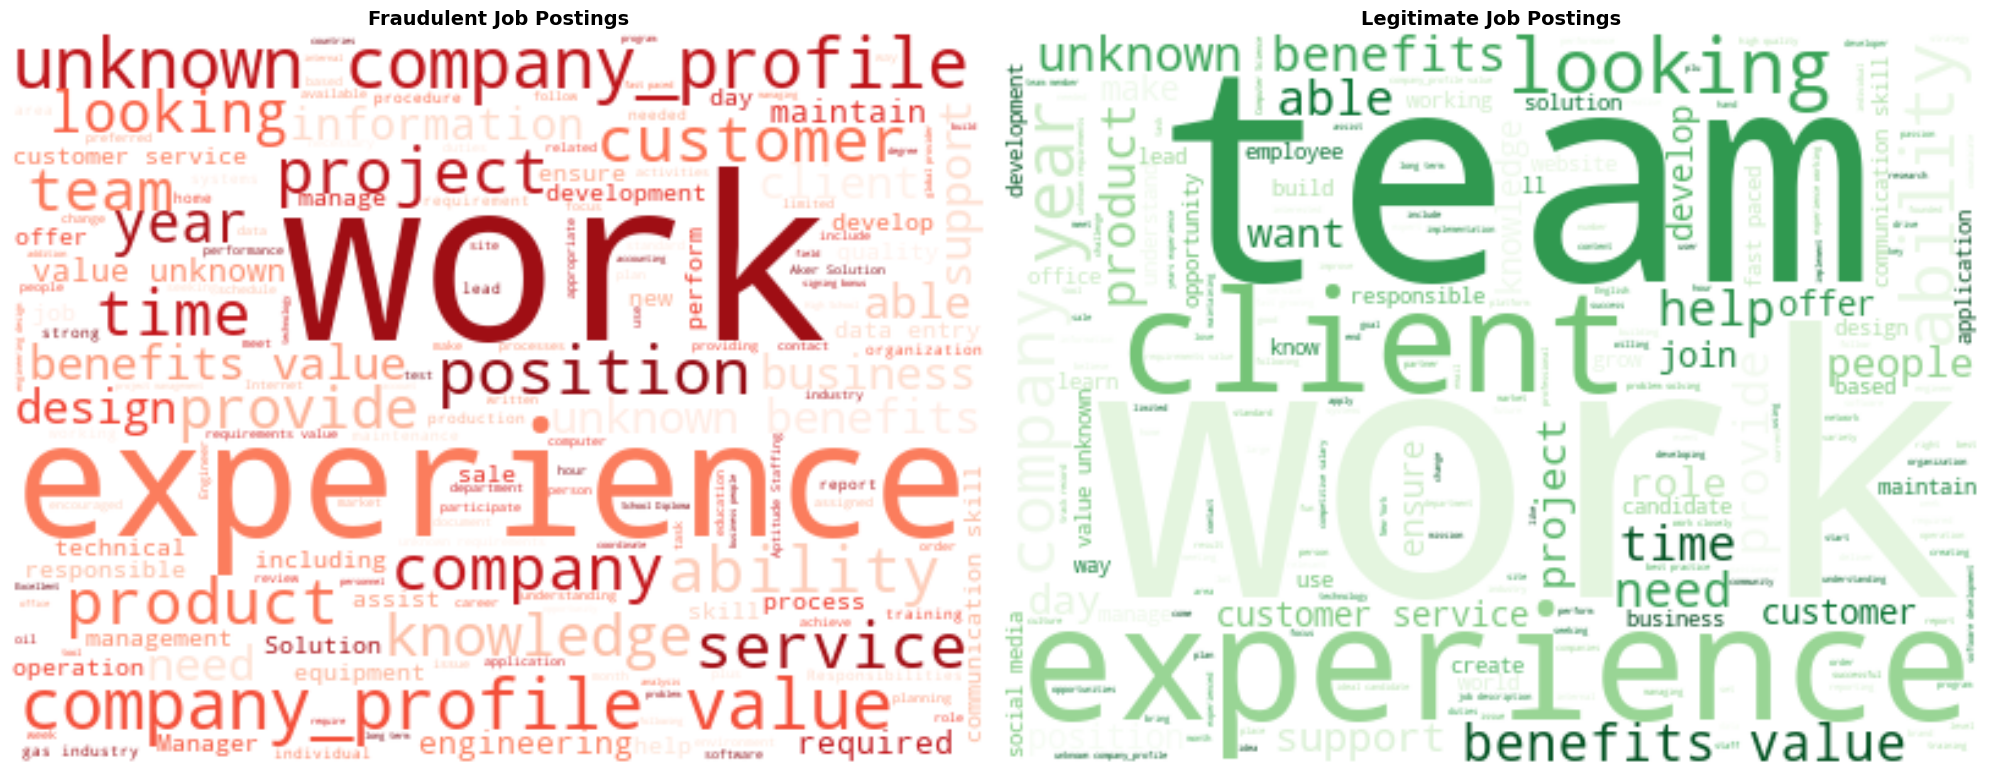

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Fraudulent wordcloud
fraudulent_wc = WordCloud(
    stopwords=ENGLISH_STOP_WORDS, width=400, height=300, 
    background_color='white', colormap='Reds'
).generate(' '.join(fraudulent_text))

ax1.imshow(fraudulent_wc, interpolation='bilinear')
ax1.set_title('Fraudulent Job Postings', fontsize=14, fontweight='bold')
ax1.axis('off')

# Legitimate wordcloud  
legitimate_wc = WordCloud(
    stopwords=ENGLISH_STOP_WORDS, width=400, height=300,
    background_color='white', colormap='Greens'
).generate(' '.join(legitimate_text))

ax2.imshow(legitimate_wc, interpolation='bilinear')
ax2.set_title('Legitimate Job Postings', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


### Section 7: Anomaly & Outlier Detection

As the rubric includes a section for analyzing outliers and anomalies, we analyze any outliers within salary range, which is 83% null.

In [24]:
job_postings_outliers_df = job_postings_clean.copy()

In [25]:
# Apply parsing
job_postings_outliers_df['salary_min'], job_postings_outliers_df['salary_max'], job_postings_outliers_df['salary_status'] = zip(*job_postings_outliers_df['salary_range'].apply(parse_salary_range))
job_postings_outliers_df['salary_mid'] = (job_postings_outliers_df['salary_min'] + job_postings_outliers_df['salary_max']) / 2
job_postings_outliers_df['salary_spread'] = job_postings_outliers_df['salary_max'] - job_postings_outliers_df['salary_min']

job_postings_outliers_df[['salary_min', 'salary_mid', 'salary_spread']].dropna()

,salary_min,salary_mid,salary_spread
6,20000.0,24000.0,8000.0
10,100000.0,110000.0,20000.0
15,120000.0,135000.0,30000.0
23,100000.0,110000.0,20000.0
31,50000.0,57500.0,15000.0
...,...,...,...
17844,0.0,0.0,0.0
17849,80000.0,90000.0,20000.0
17865,18000.0,19000.0,2000.0
17867,18000.0,18500.0,1000.0


In [26]:
# Extract country/currency
job_postings_outliers_df['currency'] = job_postings_outliers_df['location'].apply(extract_country_from_location)

# Currency conversion factors (approximate)
currency_to_usd = {
    'USD': 1.0,
    'GBP': 1.34,
    'EUR': 1.15,
    'CAD': 0.73,
    'AUD': 0.70,
    'INR': 0.012,
    'Unknown': 1.0  # Default to USD
}

# Normalize salaries to USD
job_postings_outliers_df['salary_min_usd'] = job_postings_outliers_df.apply(lambda x: x['salary_min'] * currency_to_usd.get(x['currency'], 1.0) 
            if pd.notna(x['salary_min']) else np.nan, axis=1)

job_postings_outliers_df['salary_mid_usd'] = job_postings_outliers_df.apply(lambda x: x['salary_mid'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_mid']) else np.nan, axis=1)
job_postings_outliers_df['salary_max_usd'] = job_postings_outliers_df.apply(lambda x: x['salary_max'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_max']) else np.nan, axis=1)

job_postings_outliers_df[['salary_min_usd', 'salary_mid_usd', 'salary_max_usd']].dropna()

,salary_min_usd,salary_mid_usd,salary_max_usd
6,20000.0,24000.0,28000.0
10,100000.0,110000.0,120000.0
15,120000.0,135000.0,150000.0
23,100000.0,110000.0,120000.0
31,50000.0,57500.0,65000.0
...,...,...,...
17844,0.0,0.0,0.0
17849,80000.0,90000.0,100000.0
17865,18000.0,19000.0,20000.0
17867,18000.0,18500.0,19000.0


In [27]:
salary_outliers_df = detect_salary_outliers(job_postings_outliers_df.dropna())
salary_outliers_df[salary_outliers_df['fraudulent'] == 1]

,job_id,title,location,department,salary_range,telecommuting,has_company_logo,has_questions,employment_type,required_experience,...,text,salary_min,salary_max,salary_status,salary_mid,salary_spread,currency,salary_min_usd,salary_mid_usd,salary_max_usd
5073,5074,Junior Engineer/Engineering Technician,"US, CA, San Jose","Engineering, Pipeline Design",6266624-8582080,0,0,1,Full-time,Entry level,...,"Founded in 1866, San Jose Water Company is an...",6266624.0,8582080.0,valid,7424352.0,2315456.0,Unknown,6266624.0,7424352.0,8582080.0
5687,5688,Network Marketing,"US, TX,",unknown department value,7200-1380000,0,0,0,Full-time,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
5691,5692,Network Marketing,"US, DE,",unknown department value,7200-1380000,0,0,0,Other,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
6056,6057,Payroll Data Entry Clerk Position - Earn $100...,"US, PA, Aaronsburg",Clerical,250000-500000,1,0,0,Full-time,Not Applicable,...,This job requires you to have the ability to o...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,375000.0,500000.0
6057,6058,Payroll Data Entry Clerk Position - Earn $100...,"GB, ABD, Ackerman",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,This job requires you to have the ability to o...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,375000.0,500000.0
6058,6059,Payroll Data Entry Clerk Position - Earn $100...,"GB, ABD,",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,This job requires you to have the ability to o...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,375000.0,500000.0
6846,6847,Network Marketing,"US, MD,",unknown department value,7200-1380000,0,0,0,Full-time,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
6851,6852,Network Marketing,"US, FL,",unknown department value,7200-1380000,0,0,0,Full-time,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
6854,6855,Network Marketing,"US, AK,",unknown department value,7200-1380000,0,0,0,Other,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
8722,8723,Hiring for Business Intelligence and Analytic...,"US, WA, Bellevue",unknown department value,140000-160000,0,0,0,Full-time,Mid-Senior level,...,"Position :Manager, Software DevelopmentJob Typ...",140000.0,160000.0,valid,150000.0,20000.0,Unknown,140000.0,150000.0,160000.0


While we explored salary range outliers via standardization of currencies to USD, only 8 rows are fraudulent, so salary_range can be dropped from training features.

## Section 8: Create Numerical, Categorical, TFIDF Features

In [28]:
# ── Apply feature engineering to full dataframe ───────────────────────────────
salary_parsed = job_postings_clean['salary_range'].apply(
    lambda x: pd.Series(parse_salary_range(x), index=['salary_min', 'salary_max', 'salary_validity'])
)

job_postings_clean = pd.concat([job_postings_clean, salary_parsed], axis=1)
job_postings_clean['salary_range_width'] = (
    job_postings_clean['salary_max'] - job_postings_clean['salary_min']
)
job_postings_clean['location_country'] = job_postings_clean['location'].apply(
    extract_country_from_location
)

In [29]:
num_features = [col for col in job_postings_clean.columns if bool(re.search(r'_(len|wc)$|missing', col))]

num_features_tree = num_features + ['salary_min', 'salary_max', 'salary_range_width']
num_features_tree

['missing_count',
 'description_len',
 'description_wc',
 'company_profile_len',
 'company_profile_wc',
 'requirements_len',
 'requirements_wc',
 'benefits_len',
 'benefits_wc',
 'salary_min',
 'salary_max',
 'salary_range_width']

In [30]:
cat_features = ['department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

cat_features_tree = cat_features+ ['location_country', 'salary_validity']

In [31]:
numeric_transformer = Pipeline([
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

tfidf_title = Pipeline([
  ('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))
])

tfidf_text = Pipeline([
  ('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))
])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features),
    ('tfidf_title', tfidf_title, 'title'),
    ('tfidf_text', tfidf_text, 'text')
  ],
  remainder='drop'
)

### Dropping Columns

The following columns are dropped from feature selection:
- job_id, unique ID for each job application
- salary related features. With 86% missing and roughy equivalent percentages of legitimate and fraudulent counts, likely little impact on predictions.

### Section 9: Train/Test Split

With your data prepared, split it into a train and test set.

In [32]:
job_postings_sans_salary_location = job_postings_clean.loc[:, ~job_postings_clean.columns.str.contains("salary|location|currency", case=False, regex=True)]

X = job_postings_sans_salary_location.drop(columns=['job_id', 'salary_range', 'fraudulent'], errors='ignore')
X_tree = job_postings_clean.drop(columns=['job_id', 'salary_range', 'fraudulent', 'location'])
y = job_postings_clean['fraudulent']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=RANDOM_STATE)

X_tree_train, X_tree_test, _, _ = train_test_split(
    X_tree, y, train_size=0.8, random_state=RANDOM_STATE, stratify=y
)

display(y_train.value_counts(dropna=False) / len(y_train))
display(y_test.value_counts(dropna=False)/len(y_test))

fraudulent
0    0.951552
1    0.048448
Name: count, dtype: float64

fraudulent
0    0.951622
1    0.048378
Name: count, dtype: float64

In [34]:
# ── X routing per model ───────────────────────────────────────────────────────
def get_X_for_model(name, split="Train"):
    if name in ["XGBoost"]:                 # use tree preprocessor
        return X_tree_train if split.lower() == "train" else X_tree_test
    return X_train if split.lower() == "train" else X_test

### Section 10: A Baseline Model

Use Logistic Regression to build a basic model on your data.  

In [35]:
baseline_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
start_time = time.time()
baseline_rf.fit(X_train, y_train)

fit_time = time.time() - start_time
rf_preds = baseline_rf.predict(X_test)

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [36]:
f1 = f1_score(y_test, rf_preds)
pr_auc = average_precision_score(y_test, rf_preds)
roc_auc = roc_auc_score(y_test, rf_preds)
recall = recall_score(y_test, rf_preds)
print("F1 Score:", f1)
print("PR AUC Score:", pr_auc)
print("ROC AUC Score:", roc_auc)
print("Recall:", recall)
print(f"Fit time: {fit_time:.2f} seconds")

F1 Score: 0.6536964980544747
PR AUC Score: 0.5104372761247107
ROC AUC Score: 0.7427745664739884
Recall: 0.48554913294797686
Fit time: 4.84 seconds


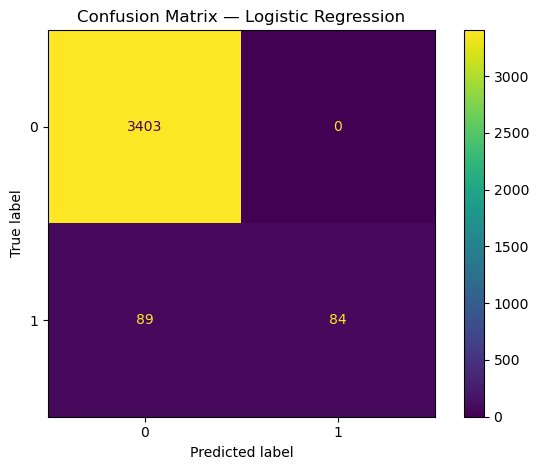

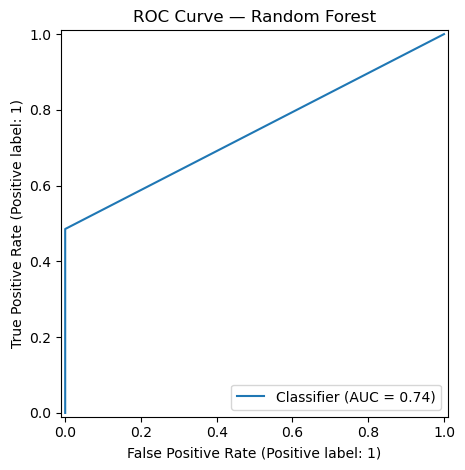

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, values_format="d")
plt.title(f"Confusion Matrix — Random Forest")
plt.tight_layout()
plt.savefig('images/baseline_model_confusion_matrix.png')
plt.show()

RocCurveDisplay.from_predictions(y_test, rf_preds)
plt.title(f"ROC Curve — Random Forest")
plt.tight_layout()
plt.savefig('images/baseline_model_roc_auc_curve.png')
plt.show()

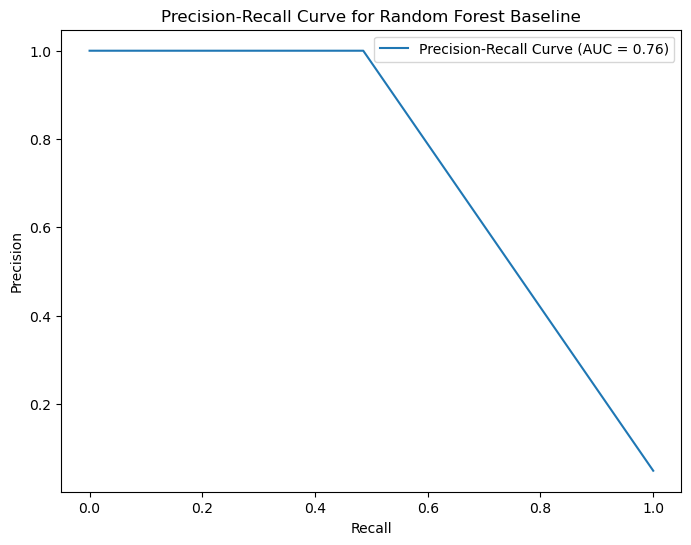

In [38]:
precision, recall, _ = precision_recall_curve(y_test, rf_preds)
auc_score = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Random Forest Baseline')
plt.legend()
plt.show()

## Baseline Selection: Random Forest over Logistic Regression

Logistic Regression and SMOTE was used as the initial baseline in earlier phases of this project but proved suboptimal for the final model evaluation. While it achieved higher recall (70.6% vs 48.6%), its F1 score (0.420) and PR-AUC (0.226) were substantially lower than Random Forest's (F1: 0.654, PR-AUC: 0.510) — indicating that Logistic Regression's recall came at the cost of excessive false positives, making it an unreliable classifier overall. 